In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/brfss_diabetes_cleaned.csv")

print("Data loaded successfully!")
print("Shape:", df.shape)

df.head()

Data loaded successfully!
Shape: (453241, 14)


,Diabetes_012,BMI,GeneralHealth,PhysicalHealthDays,MentalHealthDays,Stroke,HeartDisease,Smoker,PhysicalActivity,Sex,Age,Education,Income,HeavyAlcohol
0,0.0,22.49,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,12.0,2.0,NaN,0.0
1,0.0,25.83,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,13.0,4.0,7.0,0.0
2,0.0,22.53,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,8.0,3.0,NaN,0.0
3,0.0,25.09,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,13.0,4.0,4.0,0.0
4,0.0,19.77,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,3.0,2.0,0.0


## Exploratory Data Analysis

In this section, I will explore the cleaned BRFSS diabetes dataset to understand the distribution of the target variable and investigate relationships between diabetes and different health, demographic, and lifestyle factors.

### 1. Diabetes Target Distribution

This analysis shows the distribution of diabetic and non-diabetic respondents in the cleaned dataset.

In [3]:
target_counts = df["Diabetes_012"].value_counts().sort_index()
target_percentages = df["Diabetes_012"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary.index = ["No Diabetes", "Diabetes"]

target_summary

,Count,Percentage
No Diabetes,387432,85.48
Diabetes,65809,14.52


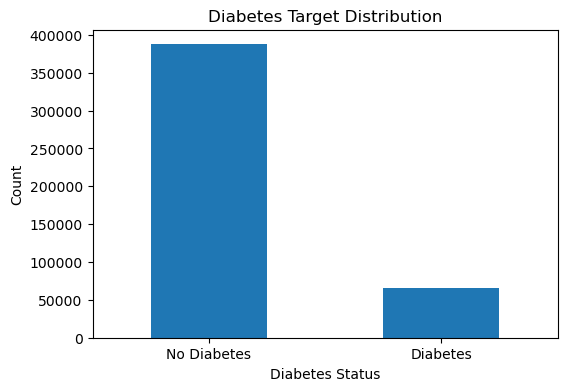

In [4]:
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.title("Diabetes Target Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Diabetes", "Diabetes"], rotation=0)

plt.show()

#### Insight

The target variable is imbalanced. Most respondents are classified as non-diabetic, representing about 85.48% of the dataset, while diabetic respondents represent about 14.52%.

This imbalance is important for the machine learning phase because accuracy alone may not be enough to evaluate the model. Metrics such as precision, recall, F1-score, and ROC-AUC should also be considered.

### 2. BMI Distribution and Diabetes Relationship

This section explores the distribution of BMI and compares BMI values between diabetic and non-diabetic respondents.

In [5]:
bmi_summary = df["BMI"].describe()

bmi_summary

count    410993.00000
mean         28.54775
std           6.57578
min          12.00000
25%          24.14000
50%          27.44000
75%          31.75000
max          99.84000
Name: BMI, dtype: float64

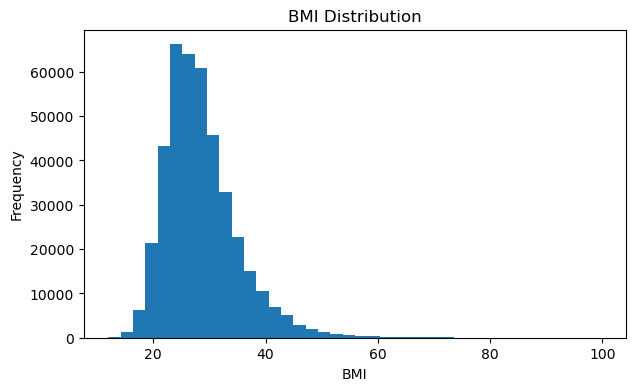

In [6]:
plt.figure(figsize=(7, 4))

df["BMI"].dropna().plot(kind="hist", bins=40)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

<Figure size 600x400 with 0 Axes>

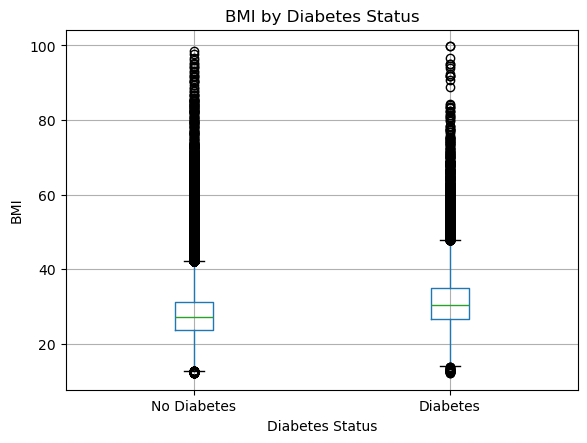

In [7]:
plt.figure(figsize=(6, 4))

df.boxplot(column="BMI", by="Diabetes_012")

plt.title("BMI by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.xticks(ticks=[1, 2], labels=["No Diabetes", "Diabetes"])

plt.show()

In [8]:
bmi_by_diabetes = df.groupby("Diabetes_012")["BMI"].mean()

bmi_by_diabetes.index = ["No Diabetes", "Diabetes"]

bmi_by_diabetes

No Diabetes    28.045616
Diabetes       31.476193
Name: BMI, dtype: float64

#### Insight

BMI appears to be higher among diabetic respondents compared to non-diabetic respondents.

The average BMI for non-diabetic respondents is about 28.05, while the average BMI for diabetic respondents is about 31.48. This suggests that higher BMI may be associated with a higher likelihood of diabetes in this dataset.

The BMI distribution is right-skewed, meaning most respondents have BMI values between 20 and 40, while fewer respondents have very high BMI values.

### 3. General Health and Diabetes

This section explores the relationship between general health status and diabetes.

In [9]:
general_health_counts = pd.crosstab(
    df["GeneralHealth"],
    df["Diabetes_012"]
)

general_health_counts.index = ["Fair/Poor Health", "Good/Better Health"]
general_health_counts.columns = ["No Diabetes", "Diabetes"]

general_health_counts

,No Diabetes,Diabetes
Fair/Poor Health,62367,26770
Good/Better Health,324064,38798


In [10]:
general_health_percentages = pd.crosstab(
    df["GeneralHealth"],
    df["Diabetes_012"],
    normalize="index"
) * 100

general_health_percentages.index = ["Fair/Poor Health", "Good/Better Health"]
general_health_percentages.columns = ["No Diabetes", "Diabetes"]

general_health_percentages.round(2)

,No Diabetes,Diabetes
Fair/Poor Health,69.97,30.03
Good/Better Health,89.31,10.69


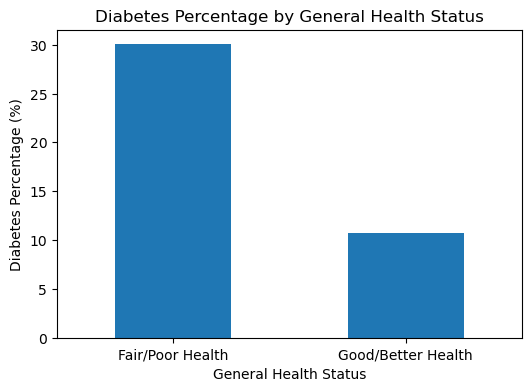

In [11]:
general_health_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by General Health Status")
plt.xlabel("General Health Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

#### Insight

Respondents with fair or poor general health have a much higher diabetes percentage compared to respondents with good or better general health.

About 30.03% of respondents with fair or poor health have diabetes, compared to only 10.69% among respondents with good or better health.

This suggests that general health status is strongly associated with diabetes in this dataset.

### 4. Age Group and Diabetes

This section explores how diabetes percentage changes across different age groups.

In [12]:
age_diabetes_percentages = pd.crosstab(
    df["Age"],
    df["Diabetes_012"],
    normalize="index"
) * 100

age_diabetes_percentages.columns = ["No Diabetes", "Diabetes"]

age_diabetes_percentages.round(2)

,No Diabetes,Diabetes
Age,,
1.0,98.58,1.42
2.0,98.08,1.92
3.0,97.10,2.90
4.0,95.60,4.40
5.0,92.96,7.04
6.0,89.19,10.81
7.0,84.96,15.04
8.0,82.29,17.71
9.0,80.26,19.74


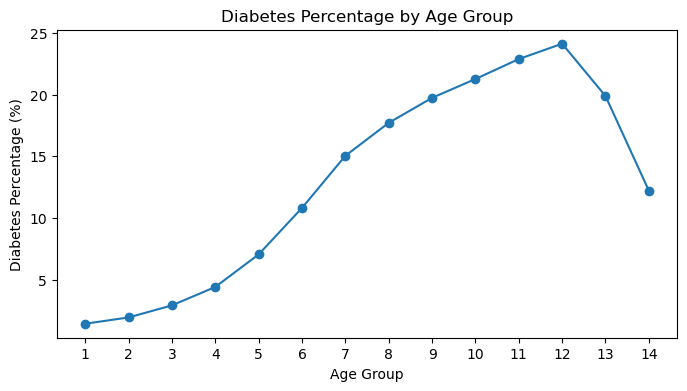

In [13]:
age_diabetes_percentages["Diabetes"].plot(kind="line", marker="o", figsize=(8, 4))

plt.title("Diabetes Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(age_diabetes_percentages.index)

plt.show()

In [14]:
lowest_age_group = age_diabetes_percentages["Diabetes"].idxmin()
lowest_percentage = age_diabetes_percentages["Diabetes"].min()

highest_age_group = age_diabetes_percentages["Diabetes"].idxmax()
highest_percentage = age_diabetes_percentages["Diabetes"].max()

print("Lowest diabetes percentage age group:")
print(lowest_age_group, round(lowest_percentage, 2))

print("\nHighest diabetes percentage age group:")
print(highest_age_group, round(highest_percentage, 2))

Lowest diabetes percentage age group:
1.0 1.42

Highest diabetes percentage age group:
12.0 24.13


#### Insight

Diabetes percentage generally increases as age group increases.

The lowest diabetes percentage appears in age group 1, with about 1.42%, while the highest percentage appears in age group 12, with about 24.13%.

This suggests that older age groups are more likely to have diabetes in this dataset. However, the percentage decreases after age group 12, which may be due to differences in sample size, survival bias, or demographic distribution in the oldest age groups.

### 5. Physical Activity and Diabetes

This section explores the relationship between physical activity and diabetes.

In [15]:
physical_activity_counts = pd.crosstab(
    df["PhysicalActivity"],
    df["Diabetes_012"]
)

physical_activity_counts.index = ["No Physical Activity", "Had Physical Activity"]
physical_activity_counts.columns = ["No Diabetes", "Diabetes"]

physical_activity_counts

,No Diabetes,Diabetes
No Physical Activity,80356,24803
Had Physical Activity,306100,40748


In [16]:
physical_activity_percentages = pd.crosstab(
    df["PhysicalActivity"],
    df["Diabetes_012"],
    normalize="index"
) * 100

physical_activity_percentages.index = ["No Physical Activity", "Had Physical Activity"]
physical_activity_percentages.columns = ["No Diabetes", "Diabetes"]

physical_activity_percentages.round(2)

,No Diabetes,Diabetes
No Physical Activity,76.41,23.59
Had Physical Activity,88.25,11.75


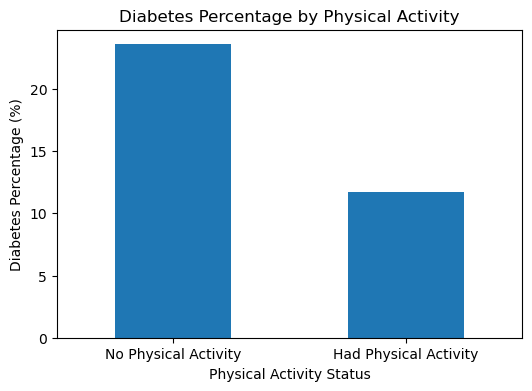

In [17]:
physical_activity_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by Physical Activity")
plt.xlabel("Physical Activity Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

#### Insight

Respondents who reported no physical activity have a higher diabetes percentage compared to respondents who had physical activity.

About 23.59% of respondents with no physical activity have diabetes, while only 11.75% of respondents who had physical activity have diabetes.

This suggests that physical activity may be associated with a lower diabetes percentage in this dataset.

### 6. Heart Disease, Stroke, and Diabetes

This section explores the relationship between diabetes and two major health conditions: heart disease and stroke.

In [18]:
def diabetes_percentage_by_binary_feature(data, feature, labels):
    """
    Calculate diabetes percentage by a binary feature.
    
    Parameters:
    data: DataFrame
    feature: column name of the binary feature
    labels: list of labels for feature values [0, 1]
    """
    percentages = pd.crosstab(
        data[feature],
        data["Diabetes_012"],
        normalize="index"
    ) * 100
    
    percentages.index = labels
    percentages.columns = ["No Diabetes", "Diabetes"]
    
    return percentages.round(2)

In [19]:
heart_disease_percentages = diabetes_percentage_by_binary_feature(
    df,
    "HeartDisease",
    ["No Heart Disease", "Heart Disease"]
)

heart_disease_percentages

,No Diabetes,Diabetes
No Heart Disease,87.60,12.40
Heart Disease,66.21,33.79


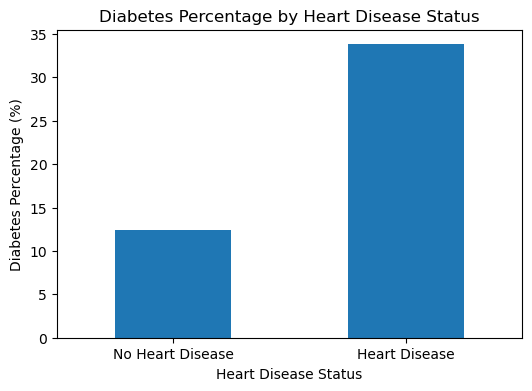

In [20]:
heart_disease_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [21]:
stroke_percentages = diabetes_percentage_by_binary_feature(
    df,
    "Stroke",
    ["No Stroke", "Stroke"]
)

stroke_percentages

,No Diabetes,Diabetes
No Stroke,86.36,13.64
Stroke,67.40,32.60


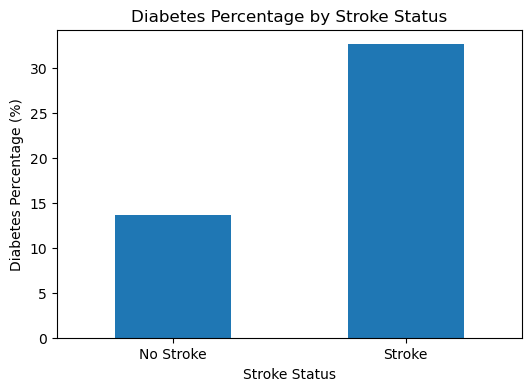

In [22]:
stroke_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by Stroke Status")
plt.xlabel("Stroke Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

#### Insight

Diabetes percentage is much higher among respondents with heart disease or stroke.

For heart disease, about 33.79% of respondents with heart disease have diabetes, compared to 12.40% among respondents without heart disease.

For stroke, about 32.60% of respondents with stroke have diabetes, compared to 13.64% among respondents without stroke.

This suggests that diabetes is strongly associated with other serious health conditions such as heart disease and stroke in this dataset.

### 7. Physical and Mental Health Days by Diabetes Status

This section compares the average number of physically and mentally unhealthy days between diabetic and non-diabetic respondents.

In [23]:
health_days_by_diabetes = df.groupby("Diabetes_012")[[
    "PhysicalHealthDays",
    "MentalHealthDays"
]].mean()

health_days_by_diabetes.index = ["No Diabetes", "Diabetes"]

health_days_by_diabetes.round(2)

,PhysicalHealthDays,MentalHealthDays
No Diabetes,4.03,4.29
Diabetes,8.00,5.01


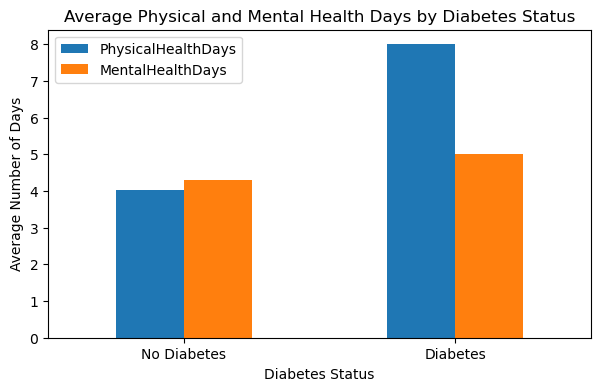

In [24]:
health_days_by_diabetes.plot(kind="bar", figsize=(7, 4))

plt.title("Average Physical and Mental Health Days by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("Average Number of Days")
plt.xticks(rotation=0)

plt.show()

<Figure size 600x400 with 0 Axes>

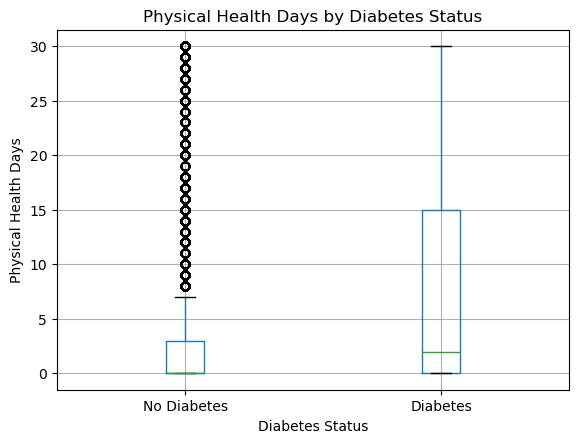

In [25]:
plt.figure(figsize=(6, 4))

df.boxplot(column="PhysicalHealthDays", by="Diabetes_012")

plt.title("Physical Health Days by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes Status")
plt.ylabel("Physical Health Days")
plt.xticks(ticks=[1, 2], labels=["No Diabetes", "Diabetes"])

plt.show()

<Figure size 600x400 with 0 Axes>

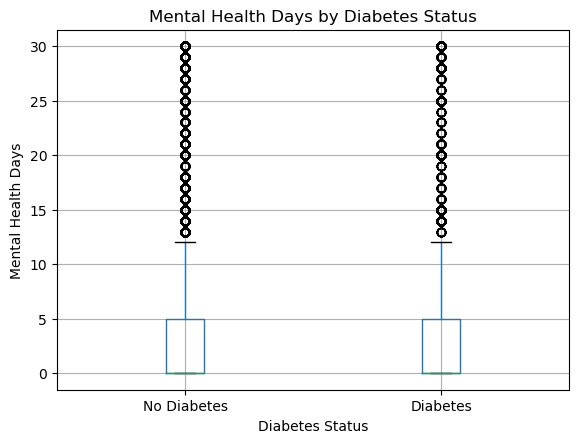

In [26]:
plt.figure(figsize=(6, 4))

df.boxplot(column="MentalHealthDays", by="Diabetes_012")

plt.title("Mental Health Days by Diabetes Status")
plt.suptitle("")
plt.xlabel("Diabetes Status")
plt.ylabel("Mental Health Days")
plt.xticks(ticks=[1, 2], labels=["No Diabetes", "Diabetes"])

plt.show()

#### Insight

Diabetic respondents report a higher average number of physically unhealthy days compared to non-diabetic respondents.

The average number of physical health days is about 4.03 for non-diabetic respondents, compared to 8.00 for diabetic respondents. This indicates that diabetic respondents tend to experience more physically unhealthy days.

For mental health days, the difference is smaller. Non-diabetic respondents report an average of about 4.29 mentally unhealthy days, while diabetic respondents report about 5.01 days.

Overall, diabetes appears to be more strongly associated with physical health limitations than mental health days in this dataset.

### 8. Smoking, Heavy Alcohol, and Diabetes

This section explores the relationship between diabetes and lifestyle-related factors such as smoking and heavy alcohol consumption.

In [27]:
smoker_percentages = diabetes_percentage_by_binary_feature(
    df,
    "Smoker",
    ["Never Smoker", "Smoker / Former Smoker"]
)

smoker_percentages

,No Diabetes,Diabetes
Never Smoker,87.22,12.78
Smoker / Former Smoker,82.69,17.31


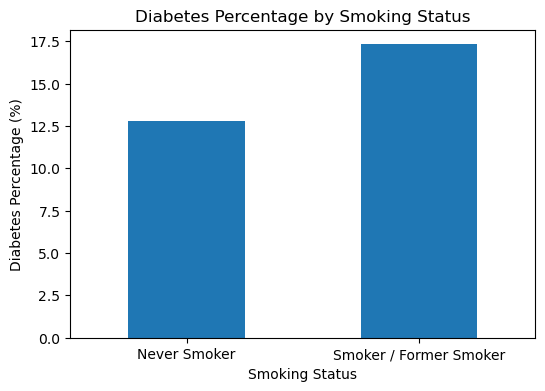

In [28]:
smoker_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [29]:
heavy_alcohol_percentages = diabetes_percentage_by_binary_feature(
    df,
    "HeavyAlcohol",
    ["Not Heavy Alcohol", "Heavy Alcohol"]
)

heavy_alcohol_percentages

,No Diabetes,Diabetes
Not Heavy Alcohol,84.88,15.12
Heavy Alcohol,92.98,7.02


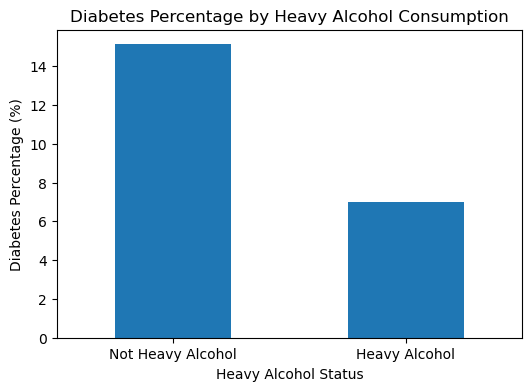

In [30]:
heavy_alcohol_percentages["Diabetes"].plot(kind="bar", figsize=(6, 4))

plt.title("Diabetes Percentage by Heavy Alcohol Consumption")
plt.xlabel("Heavy Alcohol Status")
plt.ylabel("Diabetes Percentage (%)")
plt.xticks(rotation=0)

plt.show()

#### Insight

Smoking status shows a noticeable difference in diabetes percentage. About 17.31% of smokers or former smokers have diabetes, compared to 12.78% of never smokers. This suggests that smoking history may be associated with a higher diabetes percentage in this dataset.

For heavy alcohol consumption, the observed diabetes percentage is lower among heavy alcohol respondents, about 7.02%, compared to 15.12% among non-heavy alcohol respondents.

However, this result should be interpreted carefully. It does not necessarily mean that heavy alcohol consumption reduces diabetes risk. The pattern may be affected by missing values, sample composition, age distribution, or other confounding factors.

### 9. Correlation Heatmap

This section shows the correlation between the numerical variables in the cleaned dataset. It helps identify which features have stronger positive or negative relationships with diabetes.

In [31]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix.round(2)

,Diabetes_012,BMI,GeneralHealth,PhysicalHealthDays,MentalHealthDays,Stroke,HeartDisease,Smoker,PhysicalActivity,Sex,Age,Education,Income,HeavyAlcohol
Diabetes_012,1.00,0.18,-0.22,0.16,0.03,0.11,0.18,0.06,-0.14,0.02,0.21,-0.08,-0.13,-0.05
BMI,0.18,1.00,-0.15,0.11,0.08,0.01,0.04,0.01,-0.14,0.00,-0.02,-0.07,-0.06,-0.03
GeneralHealth,-0.22,-0.15,1.00,-0.52,-0.28,-0.15,-0.21,-0.13,0.25,0.02,-0.09,0.20,0.29,0.02
PhysicalHealthDays,0.16,0.11,-0.52,1.00,0.33,0.14,0.17,0.12,-0.24,-0.04,0.09,-0.12,-0.23,-0.01
MentalHealthDays,0.03,0.08,-0.28,0.33,1.00,0.05,0.03,0.09,-0.11,-0.07,-0.17,-0.08,-0.16,0.04
Stroke,0.11,0.01,-0.15,0.14,0.05,1.00,0.20,0.07,-0.08,0.00,0.14,-0.06,-0.11,-0.02
HeartDisease,0.18,0.04,-0.21,0.17,0.03,0.20,1.00,0.12,-0.10,0.07,0.23,-0.06,-0.11,-0.02
Smoker,0.06,0.01,-0.13,0.12,0.09,0.07,0.12,1.00,-0.09,0.07,0.15,-0.15,-0.13,0.11
PhysicalActivity,-0.14,-0.14,0.25,-0.24,-0.11,-0.08,-0.10,-0.09,1.00,0.07,-0.11,0.21,0.24,0.01
Sex,0.02,0.00,0.02,-0.04,-0.07,0.00,0.07,0.07,0.07,1.00,-0.07,-0.02,0.11,0.01


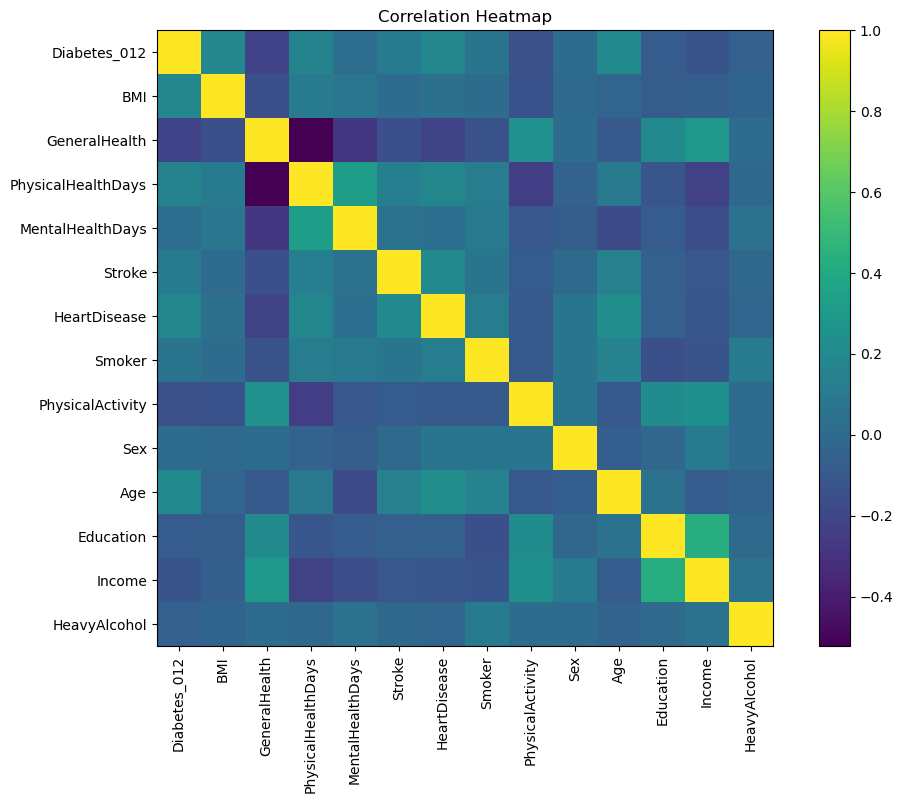

In [32]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
diabetes_correlations = correlation_matrix["Diabetes_012"].sort_values(ascending=False)

diabetes_correlations

Diabetes_012          1.000000
Age                   0.207558
BMI                   0.184409
HeartDisease          0.177662
PhysicalHealthDays    0.155605
Stroke                0.111956
Smoker                0.062693
MentalHealthDays      0.029944
Sex                   0.017080
HeavyAlcohol         -0.053920
Education            -0.081345
Income               -0.128770
PhysicalActivity     -0.142048
GeneralHealth        -0.218514
Name: Diabetes_012, dtype: float64

#### Insight

The correlation heatmap shows that diabetes has the strongest positive relationships with age, BMI, heart disease, physical health days, and stroke.

Age and BMI show positive correlations with diabetes, which supports the previous findings that diabetes percentage increases among older respondents and respondents with higher BMI.

Heart disease, stroke, and physical health days also show positive relationships with diabetes, suggesting that diabetic respondents are more likely to report other health problems and more physically unhealthy days.

General health and physical activity have negative correlations with diabetes. This is expected because better general health and having physical activity are associated with lower diabetes percentages in the previous analysis.

However, correlation does not prove causation. These relationships only show patterns in the dataset and should be interpreted carefully.

## EDA Final Summary

The exploratory data analysis showed several important patterns related to diabetes in the BRFSS 2024 dataset.

First, the target variable is imbalanced. About 85.48% of respondents are non-diabetic, while about 14.52% are diabetic. This imbalance should be considered during the machine learning phase, and evaluation should not depend on accuracy alone.

BMI appears to be higher among diabetic respondents. The average BMI for diabetic respondents is about 31.48 compared to about 28.05 for non-diabetic respondents, suggesting a positive relationship between BMI and diabetes.

General health status shows a strong relationship with diabetes. Respondents with fair or poor general health have a much higher diabetes percentage compared to those with good or better health.

Age group is also strongly related to diabetes. Diabetes percentage generally increases as age group increases, reaching its highest level around age group 12.

Physical activity appears to be associated with lower diabetes percentage. Respondents who reported no physical activity had a higher diabetes percentage than those who had physical activity.

Heart disease and stroke are also strongly associated with diabetes. Respondents with heart disease or stroke had a much higher diabetes percentage than those without these conditions.

Physical health days show a clear difference between diabetic and non-diabetic respondents. Diabetic respondents reported more physically unhealthy days on average, while the difference in mental health days was smaller.

Smoking history showed a higher diabetes percentage among smokers or former smokers compared to never smokers. Heavy alcohol showed an unexpected lower diabetes percentage among heavy alcohol respondents, but this result should be interpreted carefully because it may be affected by missing values, sample composition, or confounding factors.

The correlation heatmap confirmed several of these findings. Diabetes had positive correlations with age, BMI, heart disease, physical health days, and stroke. It had negative correlations with good general health and physical activity.

Overall, the most important features for the next machine learning phase appear to be age, BMI, general health, physical activity, heart disease, stroke, and physical health days.